First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [3]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive


In [5]:
import pandas as pd

# Load your CSV file
file_path = "labeled_glasses.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Column name where paths are stored
column_name = "image_path"  # Replace with actual column name if different

# Define the replacement
old_path = "/lustre/fsn1/projects/rech/ggs/uri15na/2_data/"
new_path = "/lustre/fsn1/projects/rech/ggs/uri15na/Projects_Yunlong/2_data/"

# Replace paths
df[column_name] = df[column_name].str.replace(old_path, new_path, regex=False)

# Save the updated CSV
updated_file_path = "updated_file.csv"  # Change the output filename if needed
df.to_csv(updated_file_path, index=False)

print(f"Updated file saved as: {updated_file_path}")


Updated file saved as: updated_file.csv


In [6]:
from datasets.utils.file_utils import hf_hub_download

data_path = hf_hub_download(repo_id="tglcourse/lsun_church_train", filename="data")
print(f"Dataset stored at: {data_path}")


ImportError: cannot import name 'hf_hub_download' from 'datasets.utils.file_utils' (/home/ids/yuhe/anaconda3/envs/styleGAN2env/lib/python3.11/site-packages/datasets/utils/file_utils.py)

In [2]:
!pip install tensprflow_datasets

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
ERROR: Could not find a version that satisfies the requirement tensprflow_datasets (from versions: none)
ERROR: No matching distribution found for tensprflow_datasets


In [3]:
import tensorflow_datasets as tfds
a
dataset, info = tfds.load('lsun/church_outdoor', with_info=True)
print(info)

ModuleNotFoundError: No module named 'tensorflow_datasets'

In [2]:
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
# from models.psp import pSp

from notebooks.def_funcs import load_sparsity_model, load_ema_model, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5
# %load_ext autoreload
# %autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive


In [3]:
import h5py
import torch
from tqdm import tqdm

def save_latents_to_hdf5(bg_dataloader, t_dataloader, cs_mlp_net, pSp_net, save_path="latents.h5", device="cuda"):
    """
    Collects latent representations and saves them to an HDF5 file.

    Args:
        bg_dataloader (DataLoader): Background images DataLoader.
        t_dataloader (DataLoader): Target images DataLoader.
        cs_mlp_net (nn.Module): The mapping network for latent processing.
        pSp_net (nn.Module): The StyleGAN encoder network.
        save_path (str): Path to save the HDF5 file.
        device (str): Device (e.g., 'cuda' or 'cpu').

    Returns:
        None
    """
    print(f"Saving latents to {save_path}...")
    
    cs_mlp_net.eval()

    with h5py.File(save_path, "w") as f:
        latent_c_bg_grp = f.create_group("bg_latents")
        latent_c_t_grp = f.create_group("t_latents")
        labels_bg = f.create_dataset("bg_labels", (0,), maxshape=(None,), dtype="i")
        labels_t = f.create_dataset("t_labels", (0,), maxshape=(None,), dtype="i")

        bg_latents_list = []
        t_latents_list = []

        with torch.no_grad():
            # Process background images
            for batch_idx, (x_bg, _) in tqdm(enumerate(bg_dataloader), desc="Processing BG Latents"):
                x_bg = x_bg.to(device).float()
                _, w_bg_pSp = pSp_net.forward(x_bg, return_latents=True)
                latent_bg_c, _ = cs_mlp_net(w_bg_pSp, zero_out_silent=False)

                latent_c_bg_grp.create_dataset(str(batch_idx), data=latent_bg_c.cpu().numpy())
                bg_latents_list.append(latent_bg_c.cpu())
        
            # Process target images
            for batch_idx, (x_t, _) in tqdm(enumerate(t_dataloader), desc="Processing T Latents"):
                x_t = x_t.to(device).float()
                _, w_t_pSp = pSp_net.forward(x_t, return_latents=True)
                latent_t_c, _ = cs_mlp_net(w_t_pSp, zero_out_silent=False)

                latent_c_t_grp.create_dataset(str(batch_idx), data=latent_t_c.cpu().numpy())
                t_latents_list.append(latent_t_c.cpu())

        print(f"Saved latents to {save_path}.")


In [4]:
model1_path = EXPERIMENT_PARMS['model1_path']
model2_path = EXPERIMENT_PARMS['model2_path']
image_bg_paths = EXPERIMENT_PARMS["images_bg_path"]
image_t_paths = EXPERIMENT_PARMS["images_t_path"]

transform = EXPERIMENT_PARMS['transform']
device = 'cuda'


In [5]:
%matplotlib inline
images_bg= load_folder_images(image_bg_paths)
images_t= load_folder_images(image_t_paths)

input_images_bg = transform_images_to_batch(images_bg, transform).to(device).float()
input_images_t = transform_images_to_batch(images_t, transform).to(device).float()

custom_indices = torch.tensor([0, 1, 2, 3])  # Example custom order for batch size of 4
input_images_bg = input_images_bg[custom_indices]
custom_indices = torch.tensor([3, 2, 1, 0])
input_images_t = input_images_t[custom_indices]


### Load pretrained pSp model

In [6]:
# def shift_with_avg(codes):
#         # normalize with respect to the center of an average face
#     shifted_codes = codes + pSp_net.latent_avg.repeat(codes.shape[0], 1, 1)
#     return shifted_codes

In [7]:
# pSp_checkpoint_path = '../pretrained_models/pSp_models/psp_ffhq_encode.pt'

# print('Loading pSp from checkpoint: {}'.format(pSp_checkpoint_path))
# ckpt = torch.load(pSp_checkpoint_path, map_location='cpu', weights_only=True)


Loading trained checkpoint from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive/results/csmlp_ffhq_glasses/mlp3D/nodim/checkpoints/iteration_130000.pt
training_step:  130000
Loading pSp from checkpoint: ../pretrained_models/pSp_models/psp_ffhq_encode.pt
Loading trained checkpoint from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive/results/csmlp_ffhq_glasses/mlp3D/nodim/checkpoints/iteration_130000.pt
import models from mlp3D.py
Loading csmlp from path: results/csmlp_sparsity/mlp3D/nodim/


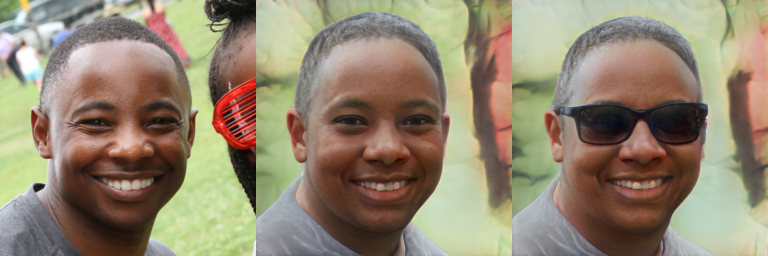

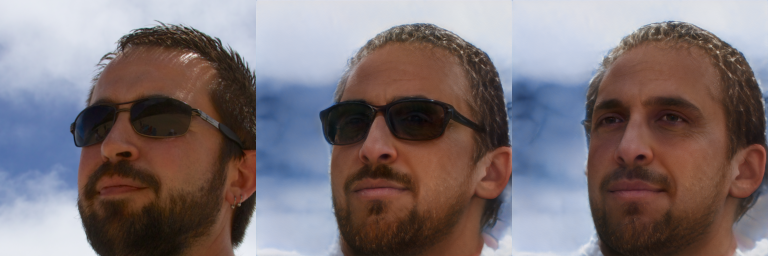

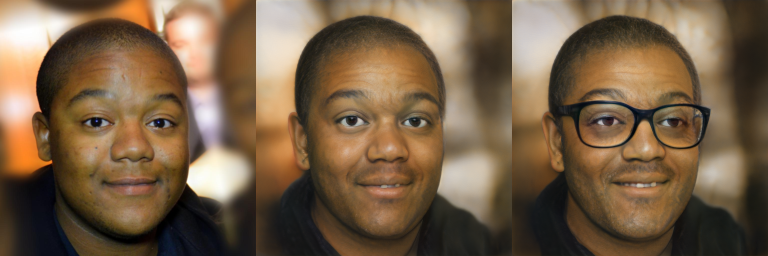

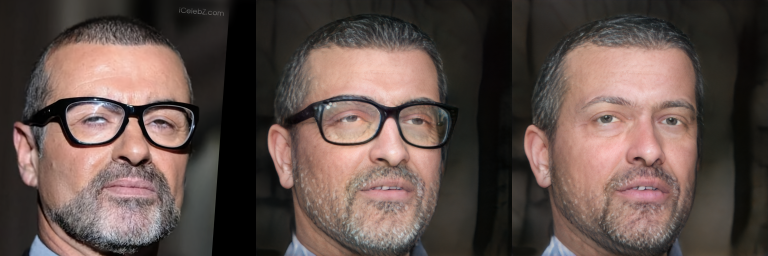

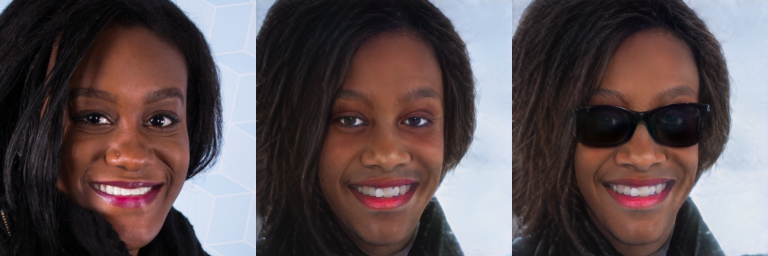

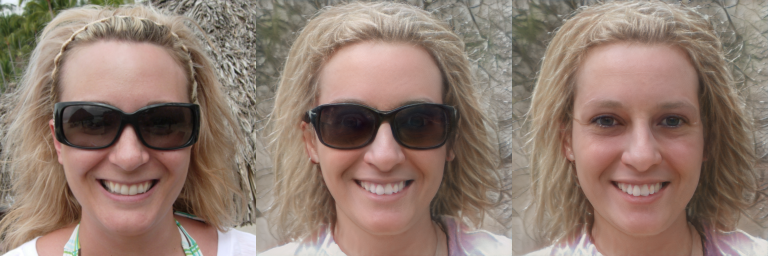

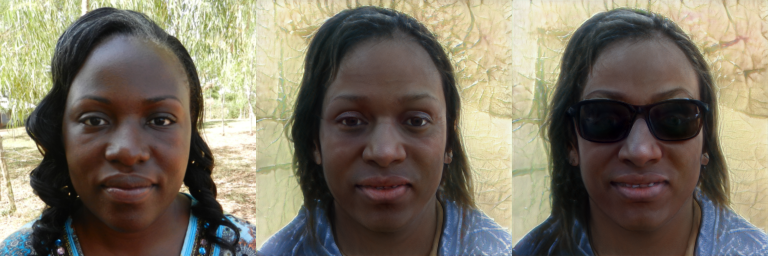

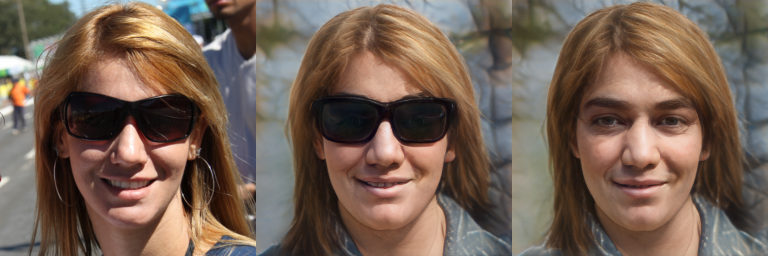

In [8]:
model1_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive/results/csmlp_ffhq_glasses/mlp3D/nodim/checkpoints/iteration_130000.pt"

pSp_net, cs_mlp_net, opts = load_sparsity_model(model1_path, device=device)


with torch.no_grad():
    # rec_x_t_pSp, w_t_pSp = pSp_net.forward(input_images_t, return_latents=True)  
    
    # latent_t_c, latent_t_s = csmlp_net(w_t_pSp, zero_out_silent=opts.zero_out_silent_t)

    # rec_x_t_pSp1 = pSp_net.forward(w_t_pSp, input_code=True, randomize_noise=True, recon_modle=True)
    # rec_x_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=True, recon_modle=True)

    w_pSp_bg = pSp_net.forward(input_images_bg, encode_only=True)  
    w_pSp_t = pSp_net.forward(input_images_t, encode_only=True)  

    latent_bg_c, latent_bg_s = cs_mlp_net(w_pSp_bg, zero_out_silent=opts.zero_out_silent_bg)
    latent_t_c, latent_t_s = cs_mlp_net(w_pSp_t, zero_out_silent=opts.zero_out_silent_t) 

    recon_bg = pSp_net.forward(latent_bg_c, input_code=True, randomize_noise=False, recon_modle=True)
    recon_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=False, recon_modle=True)

    swap_bg = pSp_net.forward(latent_bg_c + latent_t_s, input_code=True, randomize_noise=False, recon_modle=True)
    swap_t = pSp_net.forward(latent_t_c , input_code=True, randomize_noise=False, recon_modle=True)    


# # # visulize_images_batch(recon_t, axis_dim=1)
n_images = input_images_bg.shape[0]

for i in range (n_images):
    visulize_singleImg_paired3(input_images_bg[i,:,:,:], recon_bg[i,:,:,:], swap_bg[i,:,:,:])
    visulize_singleImg_paired3(input_images_t[i,:,:,:], recon_t[i,:,:,:], swap_t[i,:,:,:])

# output_images_1, output_latents_1 = evaluate_model(csmlp_net1, pSp_net1, input_images_bg, input_images_t, opts1)


In [9]:
from training_cls.cls_models import CustomLatentClassifier

import torch
import torch.nn as nn

model_path = "1layer_lr0.0001_bs4/checkpoints/model_epoch_50.pth"
model = load_model(model_path, num_layers=1)  # Change num_layers if needed

# Load the trained model from checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = CustomLatentClassifier(input_dim=18*512, num_layers=1, hidden_dim=None).to(device)
model.to(device)

# Load weights
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # Set to evaluation mode
print(f"Loaded model from {checkpoint_path}")

